In [46]:
import matplotlib.pyplot as plt
import numpy as np
import corner


In [47]:
data_curved = np.loadtxt('/Users/yhra/Documents/Master/Semester_3/BATIP/Supernova_project/Data/100K_sib_samples_curved.txt')
data_curved = np.column_stack((data_curved, 1 - data_curved[:, 1] - data_curved[:, 2]))
DATA_PATH = '/Users/yhra/Documents/Master/Semester_3/BATIP/Supernova_project/Data/'
PLOT_PATH = '/Users/yhra/Documents/Master/Semester_3/BATIP/Supernova_project/Plots/'


# Parameter Analysis

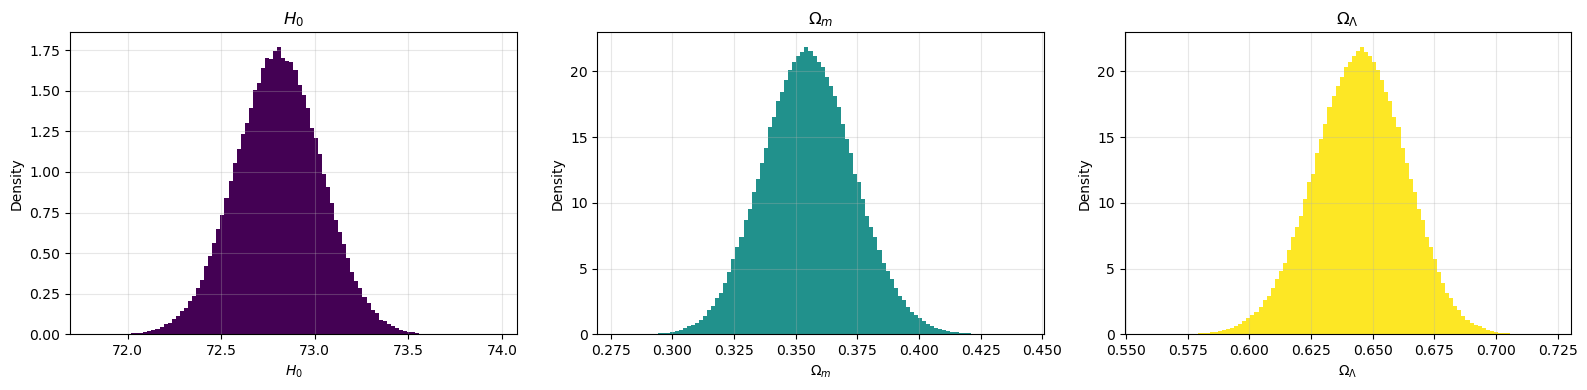

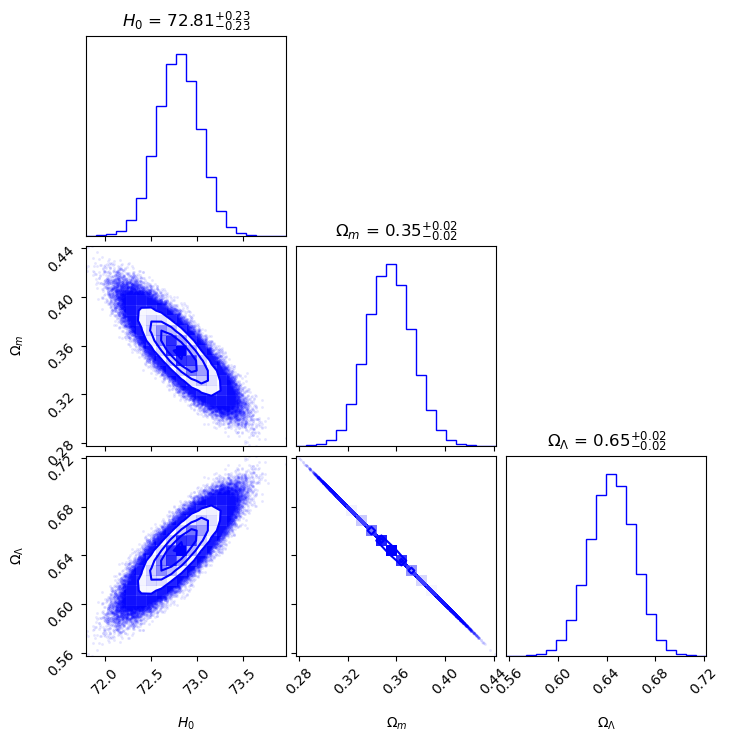

In [92]:
data = np.loadtxt(DATA_PATH + 'numpyro_samples_flat_5000_50000.txt')
type = "flat"
method = "numpyro"

# plot the data as histograms in a 4*1 grid
fig, ax = plt.subplots(1, data.shape[1], figsize=(16, 4))
colors = plt.cm.viridis(np.linspace(0, 1, data.shape[1]))
if type == "curved":
    labels = [r'$H_0$', r'$\Omega_m$', r'$\Omega_k$', r'$\Omega_\Lambda$']
else:
    labels = [r'$H_0$', r'$\Omega_m$', r'$\Omega_\Lambda$']
for i in range(data.shape[1]):
    ax[i].hist(data[:, i], bins=100, density=True, color=colors[i])
    ax[i].set_title(labels[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_xlabel(labels[i])
    ax[i].set_ylabel('Density')
plt.tight_layout()
plt.savefig(PLOT_PATH + f'parameter_analysis_{type}_{method}.png')
plt.show()

# create a corner plot for the data with confidence intervals
fig = corner.corner(
    data,
    labels=labels,
    figsize=(10, 10),
    show_titles=True,
    title_kwargs={"fontsize": 12},
    color='blue',)
plt.show()





# Binning Analysis

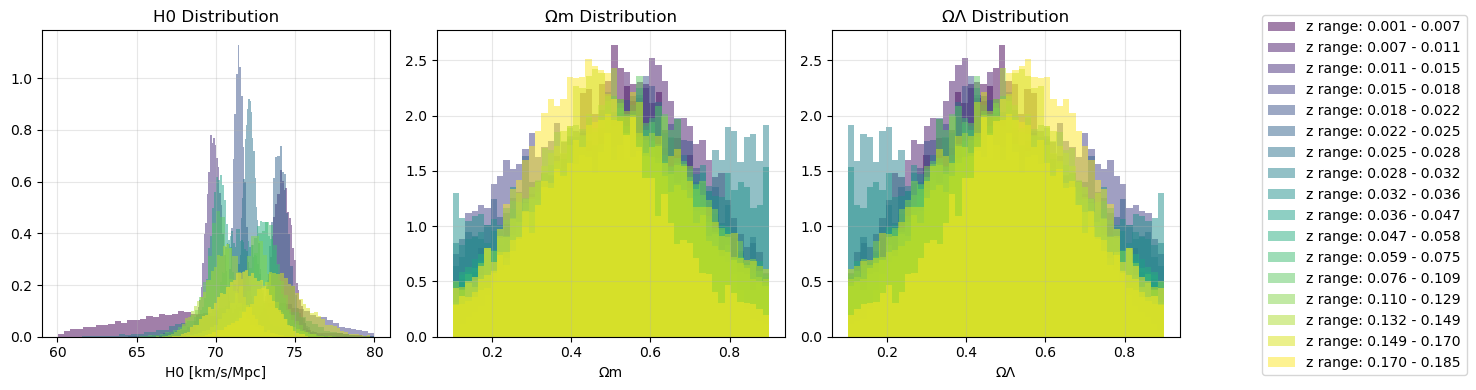

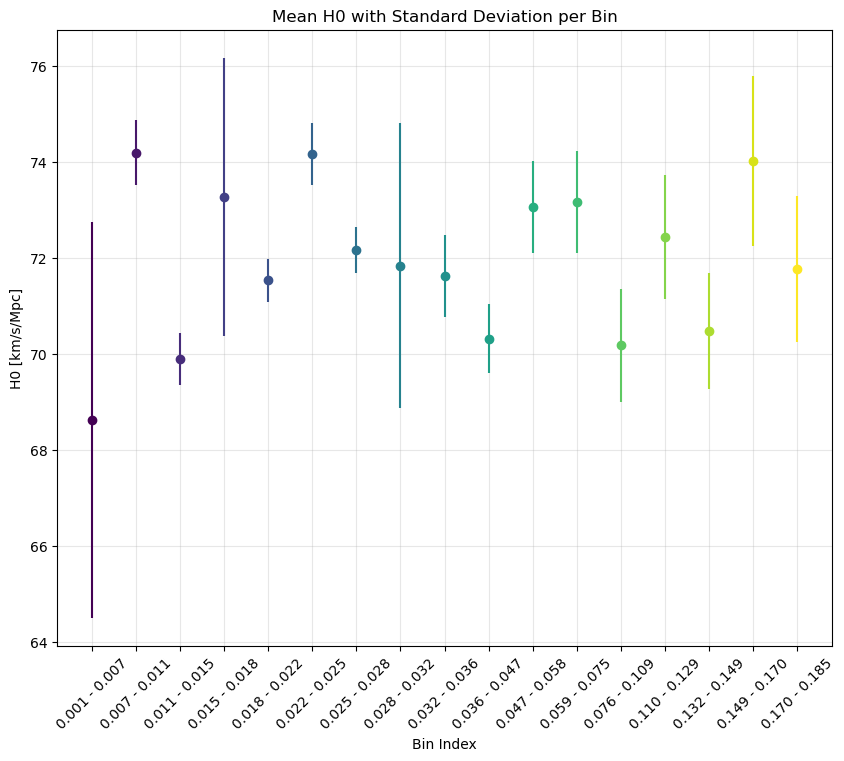

In [88]:
def plot_binned_distributions(type="curved", n_bins=10):
        # Create subplots for each parameter
        if type == "curved":
            fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
        else:
            fig, (ax1, ax2, ax4) = plt.subplots(1, 3, figsize=(12, 4))

        # load the z ranges from the file
        with open(DATA_PATH + 'z_ranges.txt', 'r') as f:
                z_ranges = [line.strip().split(' - ') for line in f.readlines()]
                z_ranges = [[float(z_min), float(z_max)] for z_min, z_max in z_ranges]
        # only keep the first n_bins z ranges
        z_ranges = z_ranges[:n_bins]

        # automatically define colors for the bins
        colors = plt.cm.viridis(np.linspace(0, 1, n_bins))
        
        # Load and plot samples from each bin
        for bin_idx in range(n_bins):
                try:
                        # Try to load samples for current bin
                        samples = np.loadtxt(DATA_PATH + f'sbi_samples_{bin_idx}_{type}.txt')
                        
                        label = f'z range: {z_ranges[bin_idx][0]:.3f} - {z_ranges[bin_idx][1]:.3f}'
                        
                        # H0 distribution
                        ax1.hist(samples[:, 0], bins=50, color=colors[bin_idx], alpha=0.5, 
                                density=True, label=label)
                        ax1.set_title('H0 Distribution')
                        
                        # Om distribution
                        ax2.hist(samples[:, 1], bins=50, color=colors[bin_idx], alpha=0.5, 
                                density=True)
                        ax2.set_title('Ωm Distribution')
                        
                        if type == "curved":
                            # Ok distribution
                            ax3.hist(samples[:, 2], bins=50, color=colors[bin_idx], alpha=0.5, 
                                    density=True)
                            ax3.set_title('Ωk Distribution')
                            # Ol distribution for curved
                            Ol = 1 - samples[:, 1] - samples[:, 2]
                        else:
                            # Ol distribution for flat
                            Ol = 1 - samples[:, 1]
                            
                        ax4.hist(Ol, bins=50, color=colors[bin_idx], alpha=0.5, 
                                density=True)
                        ax4.set_title('ΩΛ Distribution')
                
                except FileNotFoundError:
                        print(f"Warning: Could not find file for bin {bin_idx}")
                        continue
        
        # Add grid and adjust layout
        if type == "curved":
            axes = [ax1, ax2, ax3, ax4]
        else:
            axes = [ax1, ax2, ax4]
            
        for ax in axes:
                ax.grid(True, alpha=0.3)
        
        # Set axis labels
        ax1.set_xlabel('H0 [km/s/Mpc]')
        ax2.set_xlabel('Ωm')
        if type == "curved":
            ax3.set_xlabel('Ωk')
        ax4.set_xlabel('ΩΛ')
        
        # Add single legend outside the plots
        fig.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
        
        plt.tight_layout()
        plt.savefig(PLOT_PATH + 'binned_distributions.png', bbox_inches='tight')

        # Plot mean and std of H0 for each bin
        plt.figure(figsize=(10, 8))
        ax = plt.gca()

        # Load and plot samples from each bin
        for bin_idx in range(n_bins):
                try:
                        # Load samples for current bin
                        samples = np.loadtxt(DATA_PATH + f'sbi_samples_{bin_idx}_{type}.txt')
                        
                        # Calculate mean and std of H0
                        H0 = samples[:, 0]
                        mean = H0.mean()
                        std = H0.std()
                        
                        # Plot error bar
                        ax.errorbar(bin_idx, mean, yerr=std, fmt='o', color=colors[bin_idx])
                        
                except FileNotFoundError:
                        print(f"Warning: Could not find file for bin {bin_idx}")
                        continue

        # Customize plot
        # set the x ticks to be the z ranges
        ax.set_xticks(np.arange(len(z_ranges)))
        ax.set_xticklabels([f'{z_range[0]:.3f} - {z_range[1]:.3f}' for z_range in z_ranges])
        # rotate the x ticks
        plt.xticks(rotation=45)
        ax.set_xlabel('Bin Index')
        ax.set_ylabel('H0 [km/s/Mpc]')
        ax.set_title('Mean H0 with Standard Deviation per Bin')
        plt.grid(True, alpha=0.3)
        plt.savefig(PLOT_PATH + f'binned_H0_{type}.png')


plot_binned_distributions(type="flat", n_bins=17)